In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)

In [2]:
import numpy as np
print((np.array(mnist.data.loc[42]).reshape(28,28)>0).astype(int))

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 

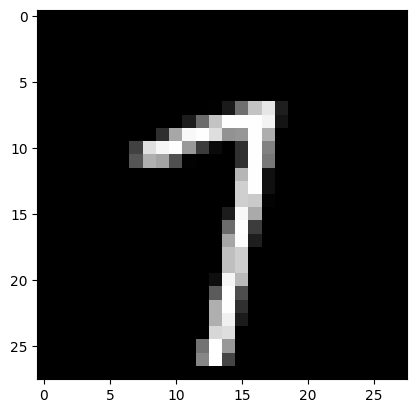

In [3]:
from matplotlib import pyplot as plt

pixels = np.array(mnist.data.loc[42]).reshape(28,28)
plt.imshow(pixels, cmap='gray')
plt.show()

In [4]:
X, y = mnist["data"], mnist["target"].astype(np.uint8)
y_sorted = y.sort_values()
X_sorted = X.reindex(y_sorted.index)
X_train, X_test = X_sorted[:56000], X_sorted[56000:]
y_train, y_test = y_sorted[:56000], y_sorted[56000:]
print("Klasy w y_train:", np.sort(y_train.unique()))
print("Klasy w y_test:", np.sort(y_test.unique()))

Klasy w y_train: [0 1 2 3 4 5 6 7]
Klasy w y_test: [7 8 9]


In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Klasy w losowym y_train:", np.sort(y_train.unique()))
print("Klasy w losowym y_test:", np.sort(y_test.unique()))

Klasy w losowym y_train: [0 1 2 3 4 5 6 7 8 9]
Klasy w losowym y_test: [0 1 2 3 4 5 6 7 8 9]


In [6]:
from sklearn.linear_model import SGDClassifier
y_train_0 = (y_train == 0)
y_test_0 = (y_test == 0)
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_0)
y_train_pred = sgd_clf.predict(X_train)
y_test_pred = sgd_clf.predict(X_test)
acc_train = sum(y_train_pred == y_train_0)/len(y_train_0)
acc_test = sum(y_test_pred == y_test_0)/len(y_test_0)
accuracy = [float(acc_train), float(acc_test)]
print(accuracy)
import pickle
with open('sgd_acc.pkl', 'wb') as file:
    pickle.dump(accuracy, file)

[0.9915892857142857, 0.9897142857142858]


In [7]:
from sklearn.model_selection import cross_val_score
score = cross_val_score(sgd_clf, X_train, y_train_0, cv=3, scoring="accuracy", n_jobs=-1)
score = np.array(score)
score = score.reshape(3,)
print(score)
with open('sgd_cva.pkl', 'wb') as file:
    pickle.dump(score, file)

[0.98467885 0.9878395  0.98671381]


In [8]:
from sklearn.metrics import confusion_matrix
sgd_m_clf = SGDClassifier(random_state = 42, n_jobs=-1)
sgd_m_clf.fit(X_train, y_train)
y_test_pred = sgd_m_clf.predict(X_test)
sgd_cmx = confusion_matrix(y_test, y_test_pred)
print(sgd_cmx)
with open('sgd_cmx.pkl', 'wb') as file:
    pickle.dump(sgd_cmx, file)

[[1216    1   34    7    0   21    8    3   12   41]
 [   0 1565    6    6    2    7    1    2    4    7]
 [   0   18 1220   35    9   11   10   19   46   12]
 [   0    8   55 1206    0   67    5   14   16   62]
 [   0    5   33    5  923    9    9   41   38  232]
 [   3    8   17   41    5 1068   18    9   58   46]
 [   1    3   61    2    2   24 1288    5    4    6]
 [   3    3   22    5    4    5    0 1411    1   49]
 [   2   21   28   60    3   60   10   10 1021  142]
 [   1    6   14   12    8    2    0   85   12 1280]]


In [9]:
from sklearn.svm import SVC
svm_clf = SVC()
svm_clf.fit(X_train, y_train)
y_test_pred = svm_clf.predict(X_test)
svc_cmx = confusion_matrix(y_test, y_test_pred)
print(svc_cmx)
with open('svc_cmx.pkl', 'wb') as file:
    pickle.dump(svc_cmx, file)

[[1329    1    3    0    1    2    2    1    4    0]
 [   0 1585    4    3    2    0    0    4    2    0]
 [   3    4 1348    2    3    2    4    8    5    1]
 [   0    2   11 1386    2   11    1    9    7    4]
 [   1    0    2    0 1269    0    3    2    2   16]
 [   0    1    2   15    2 1236    9    1    7    0]
 [   1    0    0    0    4    4 1384    0    3    0]
 [   1    6   12    1    5    1    0 1465    1   11]
 [   2    6    8   12    4    9    6    4 1303    3]
 [   5    8    2    8   14    2    0   11    5 1365]]
